# **Agent 시스템 확장_Tools**

## **1.환경준비**

### (1) 구글 드라이브

#### 1) 구글 드라이브 폴더 생성
* 새 폴더(LangGraph)를 생성하고
* 제공 받은 파일을 업로드

#### 2) 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 라이브러리

#### 1) 필요한 라이브러리 설치

In [ ]:
!pip install langchain langgraph typing typing_extensions langchain-openai langchain_core langchain-community wikipedia -q

#### 2) 라이브러리 로딩

In [ ]:
import pandas as pd
import numpy as np
import os
import openai

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

### (3) OpenAI API Key 확인

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/LangGraph/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

⚠️ 아래 코드셀은, 실행해서 key가 제대로 보이는지 확인하고 삭제하세요.

In [ ]:
print(os.environ['OPENAI_API_KEY'][:30])

## 2.간단한 Chatbot Agent 만들기

In [ ]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage, AnyMessage

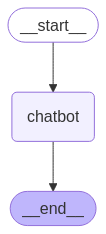

### (1) State 정의

LangGraph에서 LLM 메시지 히스토리를 자동으로 관리하기 위해 사용되는 특별한 필드 정의 방식

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]  # 리스트에 메시지를 append

### (2) Node 정의

In [ ]:
llm = ChatOpenAI(model="gpt-4.1-mini")  # 언어 모델을 gpt-4o로 설정

def chatbot(state: State):
    result = llm.invoke(state["messages"])
    return {"messages": result}   # 응답 "messages"에 넣어 반환

### (3) 그래프 정의

In [ ]:
# initiate a graph
builder = StateGraph(State)

# add a node
builder.add_node("chatbot", chatbot)

# connect nodes
builder.set_entry_point("chatbot")      # "chatbot"는 START로 연결
builder.set_finish_point("chatbot")     # "chatbot"는 END로 연결

# builder.add_edge(START, "chatbot")
# builder.add_edge("chatbot", END)

# compile the graph
graph = builder.compile()

* 그래프 시각화

In [ ]:
from IPython.display import Image, display

# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

### (4) Graph 실행

* 실행1

In [ ]:
result = graph.invoke({"messages": [HumanMessage("안녕")]})

In [ ]:
result

In [ ]:
for message in result["messages"]:
    message.pretty_print()

> 메시지 객체(HumanMessage, AIMessage 등)는 LangChain에서 제공하는 특수 클래스.  
.pretty_print()는 그 메시지를 깔끔하고 보기 좋게 출력하는 함수

* [참조]실행2
    * input을 받아서
    * .stream(...)
        * LangGraph에서 .invoke()는 전체 실행 결과를 한 번에 반환
        * 반면 .stream()은 실행되는 중간 중간 결과를 이벤트처럼 출력할 수 있어! 상태를 점진적으로 업데이트하며 리얼타임 반응처럼 처리 가능
        * 여기서는 state = {"messages": ("user", user_input)}가 전달됨
        * 즉, 사용자 메시지를 상태로 넘김
    * value["messages"][-1].content
        * 각 event는 그래프 실행 도중 생성된 중간 상태들
        * 그 중 "messages" 키의 **가장 마지막 메시지(content)**를 출력
        * 즉, 에이전트의 최신 응답만 뽑아서 보여줌

In [ ]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("잘가!")
        break
    for event in graph.stream({"messages": [HumanMessage(user_input)]}):
        for value in event.values():
            print("Assistant:", value["messages"].content)

## 3.Tool 사용하기

In [ ]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

### (1) Custom Tool 만들기

#### 1) Tool 준비하기

* langchain_core.tools의 tool을 import하면 @tool 데코레이터만으로 함수를 langchain의 tool로 변환 가능

In [ ]:
@tool
def calculator_tool(expression: str) -> str:  # type hint : 함수의 출력 type은 str
    '''수식을 입력 받아 계산하는 도구'''
    try:
        result = eval(expression)  # Python 내장 함수 eval()을 사용해서 문자열로 된 식을 계산
        return f"계산 결과: {result}"
    except Exception as e:
        return f"오류 발생: {str(e)}"

@tool
def get_weather(location: str):
    """현재 날씨 정보를 반환합니다."""
    # 입력된 지역이 "서울"인 경우에 해당하는 날씨 정보를 반환합니다.
    if location in ["서울"]:
        return "현재 온도는 20도이며 맑고 화창한 날씨입니다."
    else:
        # "서울"이 아닌 경우, 다른 날씨 정보를 반환합니다.
        return "현재 온도는 10도이며 조금 쌀쌀합니다."


#### 2) Tool 등록 및 ToolNode 생성

- tools 리스트: 정의된 tool 함수들을 리스트에 담습니다.
- ToolNode 인스턴스: 등록된 tools들을 관리하고 호출 요청을 처리하기 위해 ToolNode를 생성합니다.

In [ ]:
#Tool Node로 묶어줄 때, 리스트 형태로 tool들을 함께 제공합니다.
tools = [get_weather, calculator_tool]
tool_node = ToolNode(tools)

In [ ]:
#bind_tools() 함수로 LLM에게 어떤 tool들이 있는지 인지시켜 도구를 활용하도록 만듭니다.
from langchain_openai import ChatOpenAI

llm_with_tools = ChatOpenAI(model="gpt-4.1-mini", temperature=0
                              ).bind_tools(tools)

* tool 사용해보기

In [ ]:
llm_with_tools.invoke("서울 날씨는 어때?").tool_calls

| 필드 | 의미 |
| ---- | ---- |
| name | 사용하려는 툴의 이름 → get_weather |
| args | 툴에 넘겨줄 인자(argument) → {"location": "서울"} |
| id | 호출 ID (LangGraph나 LangChain 내부 추적용) |
| type | "tool_call" → 이 응답은 도구 호출이라는 의미 |

In [ ]:
llm_with_tools.invoke("오늘 점심은 뭐 먹을까?").tool_calls

In [ ]:
llm_with_tools.invoke("1+3*(20-15)").tool_calls

In [ ]:
tool_node.invoke({"messages": [llm_with_tools.invoke("서울 날씨는 어때?")]})

#### 3) 그래프 만들기

* 그래프 흐름
    - 내장 툴들을 불러오기 (load_tools())
    - 하나의 ToolNode에 묶기
    - LangGraph로 LLM → ToolNode → LLM 구조 실행하기


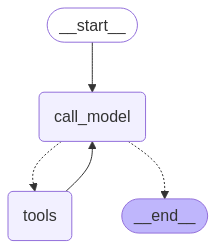

In [ ]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph

* State

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

* Node 와 분기 함수(conditional edge를 위한 함수)

In [ ]:
# 모델 호출 함수 (GPT 호출)
def call_model(state: State):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# 조건 분기 함수: 툴 호출이 필요한가?
def should_continue(state: State) -> Literal["tools", END]:  # 출력은 반드시 "tools" 혹은 END 여야 함.
    messages = state["messages"]
    last_message = messages[-1]  # 가장 최근 message
    if last_message.tool_calls:
        return "tools"
    return END

* 그래프 구성

In [ ]:
builder = StateGraph(State)

# 노드 추가
builder.add_node("call_model", call_model)
builder.add_node("tools", tool_node)

# 연결
builder.set_entry_point("call_model")
builder.add_conditional_edges("call_model", should_continue,
                            #   {"tools": "tools", END: END}
                              )
builder.add_edge("tools", "call_model")  # 루프 연결

# 컴파일
graph = builder.compile()

* 그래프 시각화

In [ ]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) 그래프 사용하기

In [ ]:
final_state = graph.invoke(
    {"messages": [HumanMessage(content="서울의 날씨는 어때?")]}
)
final_state["messages"][-1].content

In [ ]:
# example with a multiple tool calls in succession

for chunk in graph.stream(
    {"messages": [("human", "2**8")]},
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()

### (2) langchain 내장 tool 사용하기

#### 1) Tool 준비하기

* langchain_core.tools의 tool을 import하면 @tool 데코레이터만으로 함수를 langchain의 tool로 변환 가능

In [ ]:
from langchain.agents import load_tools

llm = ChatOpenAI(model="gpt-4.1-mini")
tools = load_tools(["llm-math", "wikipedia"], llm=llm) # 일부 툴이 LLM을 내부적으로 쓸 때 필요한 설정


#### 2) ToolNode 생성

In [ ]:
tool_node = ToolNode(tools)

In [ ]:
# 툴을 쓸 수 있는 LLM
llm_with_tools = llm.bind_tools(tools)  # GPT가 이 툴들을 사용하겠다고 판단할 수 있게 도와주는 설정

#### 3) 그래프 만들기

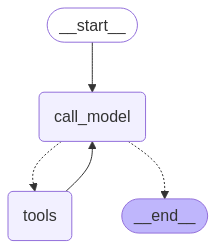

In [ ]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph

* State

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

* Node 와 분기 함수(conditional edge를 위한 함수)

In [ ]:
# 모델 호출 함수 (GPT 호출)
def call_model(state: State):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# 조건 분기 함수: 툴 호출이 필요한가?
def should_continue(state: State) -> Literal["tools", END]:  # 출력은 반드시 "tools" 혹은 END 여야 함.
    messages = state["messages"]
    last_message = messages[-1]  # 가장 최근 message
    if last_message.tool_calls:
        return "tools"
    return END

* 그래프 구성

In [ ]:
builder = StateGraph(State)

# 노드 추가
builder.add_node("call_model", call_model)
builder.add_node("tools", tool_node)

# 연결
builder.set_entry_point("call_model")
builder.add_conditional_edges("call_model", should_continue)
builder.add_edge("tools", "call_model")  # 루프 연결

# 컴파일
graph = builder.compile()

* 그래프 시각화

In [ ]:
# 외부 서버를 호출하는 동안 대기시간 초과로 오류가 날 수 있습니다.
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

#### 4) 그래프 사용하기

In [ ]:
result = graph.invoke({
    "messages": [HumanMessage(content="피타고라스의 정리를 설명해줘")]
})

# 출력
for message in result["messages"]:
    message.pretty_print()

In [ ]:
result = graph.invoke({
    "messages": [HumanMessage(content="3의 제곱근은 얼마야?")]
})

# 출력
for message in result["messages"]:
    message.pretty_print()

## 4.실습

### (1) 실습1

* LLM을 하나 생성하시오 (ChatOpenAI)
* 다음 도구 3개를 load_tools()를 사용하여 불러오고, ToolNode로 묶으시오
    * llm-math, wikipedia, serpapi
* GPT에게 도구 목록을 알려주기 위해 .bind_tools(tools)를 사용하시오
* 이를 위해 필요한 준비작업을 수행하시오.
    * serpapi api key를 받아 등록
    * 필요한 라이브러리 설치

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt.tool_node import ToolNode
from langchain.agents import load_tools
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from typing import Literal, Annotated
from typing_extensions import TypedDict
from langchain_core.tools import tool

#### 1) Tool 준비하기

In [ ]:
!pip install google-search-results -q


#### 2) ToolNode 생성

#### 3) 그래프 만들기

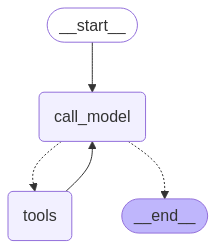

* State

* Node 와 분기 함수(conditional edge를 위한 함수)

* 그래프 구성

* 그래프 시각화

#### 4) 그래프 사용하기

### (3) 실습2

* 날씨 기반 의상 추천 에이전트
    * 지역 날씨 정보를 조회한 뒤
    * 해당 날씨에 맞는 옷차림을 추천하는
    * Tool 사용 기반 LangChain Agent
* 요구사항
    * get_weather 툴 정의 : 서울, 부산, 제주 중 입력받은 지역의 날씨 정보 반환
    * recommend_clothing 툴 정의 : 전달받은 날씨 정보(문자열)를 기반으로 옷차림 추천
    * 두 툴을 등록하여 에이전트 생성

* 사용자 질문 : "서울 날씨에 맞는 옷차림 추천해줘"
를 넣었을 때 → 날씨 툴 호출 → 옷 추천 툴 호출 → 답변

#### 1) Tool 준비하기


#### 2) ToolNode 생성

#### 3) 그래프 만들기

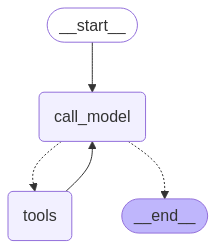

* State

* Node 와 분기 함수(conditional edge를 위한 함수)

* 그래프 구성

* 그래프 시각화

#### 4) 그래프 사용하기